# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hacker3code/Flyrank-AI/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

### Research question

Can a simple rule using February 2026 search visibility and CTR relative to average position identify pages that are worth prioritizing for review?

### Decision supported

The rule is intended as a decision-support tool for ranking content pages for review. It prioritizes pages that have meaningful search visibility but appear to capture relatively few clicks for their observed average position.

This is a baseline ranking rule, not a causal model. It does not claim that changing a page will improve Google rankings or clicks.

### Baseline rule

Prioritize pages with:

1. measurable February GSC impressions,
2. relatively strong search visibility,
3. a low CTR compared with pages at similar observed average positions.

The score combines normalized search volume with a position-aware CTR opportunity signal. Higher scores receive higher review priority.

### Reason code

**R1_CTR_POSITION_OPPORTUNITY** — the page has observed search visibility and its CTR appears low relative to its observed average position, making it a candidate for review.

### Action label

**PRIORITIZE_REVIEW**


In [1]:
# SECTION 1 — Question / rule definition

print("Research question:")
print(
    "Can February search visibility and CTR relative to average position "
    "identify pages worth prioritizing for review?"
)

print("\nDecision supported:")
print(
    "Rank content pages for review using observed February search signals."
)

print("\nRule:")
print(
    "Prioritize pages with meaningful search visibility and low CTR "
    "relative to their observed average position."
)

print("\nReason code:")
print("R1_CTR_POSITION_OPPORTUNITY")

print("\nAction:")
print("PRIORITIZE_REVIEW")

Research question:
Can February search visibility and CTR relative to average position identify pages worth prioritizing for review?

Decision supported:
Rank content pages for review using observed February search signals.

Rule:
Prioritize pages with meaningful search visibility and low CTR relative to their observed average position.

Reason code:
R1_CTR_POSITION_OPPORTUNITY

Action:
PRIORITIZE_REVIEW


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

In [2]:
import os
import getpass
import duckdb
import pandas as pd
import numpy as np

token = getpass.getpass("Paste your Hugging Face READ token: ")

assert token.startswith("hf_"), "Invalid Hugging Face token."

os.environ["HF_TOKEN"] = token

con = duckdb.connect()

con.execute("INSTALL httpfs")
con.execute("LOAD httpfs")

print("Connected.")

Paste your Hugging Face READ token: ··········
Connected.


In [3]:
# Authenticate DuckDB requests to Hugging Face

con.execute(f"""
    CREATE OR REPLACE SECRET hf_secret (
        TYPE http,
        EXTRA_HTTP_HEADERS MAP {{
            'Authorization': 'Bearer {token}'
        }}
    )
""")

FEB = """
read_parquet(
    'https://huggingface.co/datasets/FlyRank/internship-warehouse/resolve/main/fact_content_daily_performance/month=2026-02/data_0.parquet'
)
"""

print("Feature window: February 2026")
print("Decision date: 2026-02-28")
print("Hugging Face authentication configured.")

Feature window: February 2026
Decision date: 2026-02-28
Hugging Face authentication configured.


In [4]:
test = con.sql(f"""
SELECT *
FROM {FEB}
LIMIT 5
""").df()

print("Rows returned:", len(test))
display(test)

Rows returned: 5


,report_date,client_hash_id,content_hash_id,client_has_gsc,client_has_ga4,gsc_data_available,ga4_data_available,gsc_impressions,gsc_clicks,gsc_sum_position,...,sessions_ai,ai_chatgpt,ai_perplexity,ai_gemini,ai_copilot,ai_claude,ai_meta,ai_other,scroll_events,month
0,2026-02-01,client_e547b89c05043229,content_7995404695ee1ffd,True,True,True,False,57,0,1778,...,0,0,0,0,0,0,0,0,0,2026-02
1,2026-02-01,client_e547b89c05043229,content_1eea820697c3b95a,True,True,True,False,13,0,85,...,0,0,0,0,0,0,0,0,0,2026-02
2,2026-02-01,client_e547b89c05043229,content_ccbb253f142217c3,True,True,True,True,59,0,1001,...,0,0,0,0,0,0,0,0,0,2026-02
3,2026-02-01,client_e547b89c05043229,content_ae16a6b9cf64c80a,True,True,True,False,17,0,287,...,0,0,0,0,0,0,0,0,0,2026-02
4,2026-02-01,client_e547b89c05043229,content_acf700633f016e5a,True,True,True,False,6,0,27,...,0,0,0,0,0,0,0,0,0,2026-02


In [5]:
# SECTION 2 — Data

print("Dataset: FlyRank ML Internship warehouse")
print("Decision window: February 2026")
print("Primary table: fact_content_daily_performance")
print("Primary signals: GSC impressions, clicks, average position")
print("Derived signal: CTR = clicks / impressions")

capstone_data = con.sql(f"""
WITH feb AS (
    SELECT
        client_hash_id,
        content_hash_id,
        SUM(gsc_impressions) AS impressions_feb,
        SUM(gsc_clicks) AS clicks_feb,
        AVG(gsc_avg_position) AS avg_position_feb
    FROM {FEB}
    WHERE gsc_data_available IS TRUE
    GROUP BY
        client_hash_id,
        content_hash_id
)

SELECT
    client_hash_id,
    content_hash_id,
    impressions_feb,
    clicks_feb,
    avg_position_feb,
    CASE
        WHEN impressions_feb > 0
        THEN clicks_feb / impressions_feb
        ELSE NULL
    END AS ctr_feb
FROM feb
WHERE impressions_feb > 0
""").df()

print(
    "\nFebruary decision rows with measurable GSC impressions:",
    len(capstone_data)
)

print("\nExcluded from CTR analysis:")
print("- Rows without GSC data")
print("- Rows with zero impressions")
print("- Future-window observations")
print("- Client names, domains, URLs and private queries")

print("\nData check:")
print("Rows:", len(capstone_data))
print("Columns:", list(capstone_data.columns))

Dataset: FlyRank ML Internship warehouse
Decision window: February 2026
Primary table: fact_content_daily_performance
Primary signals: GSC impressions, clicks, average position
Derived signal: CTR = clicks / impressions


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


February decision rows with measurable GSC impressions: 153559

Excluded from CTR analysis:
- Rows without GSC data
- Rows with zero impressions
- Future-window observations
- Client names, domains, URLs and private queries

Data check:
Rows: 153559
Columns: ['client_hash_id', 'content_hash_id', 'impressions_feb', 'clicks_feb', 'avg_position_feb', 'ctr_feb']


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

The analysis uses only information available at the February 28, 2026 decision point. The main features are February search impressions, CTR, and average search position.

The baseline ranks content using a simple rule: pages with relatively strong search visibility and relatively weak CTR for their observed position receive a higher review score. The purpose is prioritization, not prediction of a guaranteed outcome.

The label for later model evaluation will be defined using a future window after the February decision date. The future window is kept separate from the February features to prevent leakage.

Validation will use a time-aware design: February information is used to create the decision features, while later observations are used only for evaluation. No future-window metric, outcome label, client name, URL, domain, or private query is used as an input feature.

The baseline is intentionally simple and interpretable. A later model must be evaluated against this same baseline on the same evaluation population before claiming improvement.


In [6]:
# SECTION 3 — Methodology checks

print("Decision date: 2026-02-28")
print("Feature window: February 2026")
print("Features used:")
print("- impressions_feb")
print("- ctr_feb")
print("- avg_position_feb")

print("\nBaseline:")
print("- Rule-based CTR/position opportunity score")
print("- Reason code: R1_CTR_POSITION_OPPORTUNITY")
print("- Action: PRIORITIZE_REVIEW")

print("\nLeakage controls:")
print("- February data only for decision features")
print("- No future-window variables used as inputs")
print("- No outcome/label-derived features")
print("- No client names, domains, URLs or private queries")

print("\nEvaluation design:")
print("- Time-aware evaluation")
print("- Future observations reserved for evaluation")
print("- Baseline and model evaluated on the same split")

print("\nMethodology check complete.")

Decision date: 2026-02-28
Feature window: February 2026
Features used:
- impressions_feb
- ctr_feb
- avg_position_feb

Baseline:
- Rule-based CTR/position opportunity score
- Reason code: R1_CTR_POSITION_OPPORTUNITY
- Action: PRIORITIZE_REVIEW

Leakage controls:
- February data only for decision features
- No future-window variables used as inputs
- No outcome/label-derived features
- No client names, domains, URLs or private queries

Evaluation design:
- Time-aware evaluation
- Future observations reserved for evaluation
- Baseline and model evaluated on the same split

Methodology check complete.


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

The Week-4 rule-based baseline produces a ranked review queue using February search visibility, CTR, and average position.

The baseline is a decision-support ranking rather than a predictive model. Its purpose is to establish a simple, transparent benchmark that a later model must beat on the same evaluation population.

The highest-ranked pages are pages where observed search visibility is relatively strong while CTR is low for their observed position. These pages are treated as review opportunities, not guaranteed optimization wins.

A model-versus-baseline performance comparison will be reported only after a future-window outcome label has been defined and evaluated using a time-aware split. No future outcome is used to create the February baseline score.


In [16]:
# SECTION 4A — Inspect future-window data

MAR = "read_parquet('https://huggingface.co/datasets/FlyRank/internship-warehouse/resolve/main/fact_content_daily_performance/month=2026-03/*.parquet?download=true')"

print("Decision window : February 2026")
print("Future window   : March 2026")
print("Purpose         : Define an out-of-time evaluation label")

Decision window : February 2026
Future window   : March 2026
Purpose         : Define an out-of-time evaluation label


In [19]:
# SECTION 4B — Inspect available warehouse partitions
#
# Do not assume March exists.
# We first inspect the dataset structure.

import requests

url = "https://huggingface.co/api/datasets/FlyRank/internship-warehouse/tree/main/fact_content_daily_performance"

response = requests.get(url)

print("HTTP status:", response.status_code)

if response.ok:
    items = response.json()

    print("\nAvailable paths:")
    for item in items:
        print(item.get("path"))
else:
    print(response.text[:1000])

HTTP status: 200

Available paths:
fact_content_daily_performance/month=2025-01
fact_content_daily_performance/month=2025-02
fact_content_daily_performance/month=2025-03
fact_content_daily_performance/month=2025-04
fact_content_daily_performance/month=2025-05
fact_content_daily_performance/month=2025-06
fact_content_daily_performance/month=2025-07
fact_content_daily_performance/month=2025-08
fact_content_daily_performance/month=2025-09
fact_content_daily_performance/month=2025-10
fact_content_daily_performance/month=2025-11
fact_content_daily_performance/month=2025-12
fact_content_daily_performance/month=2026-01
fact_content_daily_performance/month=2026-02
fact_content_daily_performance/month=2026-03
fact_content_daily_performance/month=2026-04
fact_content_daily_performance/month=2026-05
fact_content_daily_performance/month=2026-06


In [21]:
# SECTION 4B — Inspect March 2026 data

import requests

api_url = "https://huggingface.co/api/datasets/FlyRank/internship-warehouse/tree/main/fact_content_daily_performance/month=2026-03"

r = requests.get(
    api_url,
    headers={"Authorization": f"Bearer {os.environ['HF_TOKEN']}"}
)

print("HTTP status:", r.status_code)

march_files = r.json()

print("\nMarch files:")
for item in march_files:
    print(item["path"])

HTTP status: 200

March files:
fact_content_daily_performance/month=2026-03/data_0.parquet


In [8]:
# SECTION 4 — Baseline results
# Rebuild the February feature frame so this section is self-contained.
# No future-window data is used.

baseline_data = con.sql(f"""
WITH feb AS (
    SELECT
        client_hash_id,
        content_hash_id,
        SUM(gsc_impressions) AS impressions_feb,
        SUM(gsc_clicks) AS clicks_feb,
        SUM(gsc_sum_position) / NULLIF(SUM(gsc_impressions), 0)
            AS avg_position_feb
    FROM {FEB}
    WHERE gsc_data_available IS TRUE
    GROUP BY
        client_hash_id,
        content_hash_id
)

SELECT
    client_hash_id,
    content_hash_id,
    impressions_feb,
    clicks_feb,
    avg_position_feb,
    clicks_feb / NULLIF(impressions_feb, 0) AS ctr_feb
FROM feb
WHERE impressions_feb > 0
""").df()

print("BASELINE RESULTS")
print("=" * 50)

print("Decision rows:", len(baseline_data))

print("\nBaseline inputs:")
print("- February impressions")
print("- February CTR")
print("- February average position")

print("\nBaseline reason code:")
print("R1_CTR_POSITION_OPPORTUNITY")

print("\nBaseline action:")
print("PRIORITIZE_REVIEW")

print("\nBaseline data preview:")
display(baseline_data.head(10))

print("\nInterpretation:")
print(
    "The baseline uses observed February CTR, search visibility, and "
    "average position to identify pages for review. It is a transparent "
    "decision-support benchmark, not a prediction of guaranteed improvement."
)

print("\nModel comparison status:")
print(
    "A model-versus-baseline metric will only be reported after a "
    "future-window evaluation label is defined."
)

print("\nLeakage check:")
print("PASS — only February decision-window variables are used here.")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

BASELINE RESULTS
Decision rows: 153559

Baseline inputs:
- February impressions
- February CTR
- February average position

Baseline reason code:
R1_CTR_POSITION_OPPORTUNITY

Baseline action:
PRIORITIZE_REVIEW

Baseline data preview:


,client_hash_id,content_hash_id,impressions_feb,clicks_feb,avg_position_feb,ctr_feb
0,client_3ffa76342f366962,content_36bee0a093d0711d,3.0,0.0,7.000000,0.000000
1,client_3ffa76342f366962,content_1546aabff77c05a4,5.0,1.0,4.200000,0.200000
2,client_3ffa76342f366962,content_cae1d5374958a649,96.0,0.0,5.520833,0.000000
3,client_3ffa76342f366962,content_dd66eecf9626cab8,235.0,0.0,6.391489,0.000000
4,client_3ffa76342f366962,content_c51f1e8ef5502177,18.0,0.0,7.000000,0.000000
5,client_3ffa76342f366962,content_0674cc4ae0f68a90,74.0,1.0,8.027027,0.013514
6,client_3ffa76342f366962,content_0bbad1e88286bfc6,2.0,0.0,4.000000,0.000000
7,client_3ffa76342f366962,content_388b1fcec3596848,30.0,3.0,5.366667,0.100000
8,client_3ffa76342f366962,content_0ffc84b3be2f3bc1,26.0,1.0,7.038462,0.038462
9,client_3ffa76342f366962,content_456ab2db28595187,100.0,2.0,4.200000,0.020000



Interpretation:
The baseline uses observed February CTR, search visibility, and average position to identify pages for review. It is a transparent decision-support benchmark, not a prediction of guaranteed improvement.

Model comparison status:
A model-versus-baseline metric will only be reported after a future-window evaluation label is defined.

Leakage check:
PASS — only February decision-window variables are used here.


## 5. Limitations

*What this work cannot claim.*

This analysis identifies observed search opportunities from February 2026 data. A high baseline score does not guarantee that changing a page will increase clicks, rankings, or engagement.

CTR can vary because of factors that are not represented in this baseline, including query mix, search-result features, seasonality, and measurement variation. Pages with low click counts may also have unstable CTR estimates.

The analysis is therefore directional and intended for decision support and prioritization. It does not establish that any particular content change caused a performance change, and it does not claim to explain or prove Google's ranking algorithm.

Future-window outcomes will be kept separate from the February features when evaluating the later model. Any model improvement will be reported only on the same evaluation population used for the baseline.


In [9]:
# SECTION 5 — Limitations and leakage check

print("LIMITATIONS")
print("=" * 50)

print("1. The baseline identifies observed opportunities; it does not")
print("   guarantee that an action will improve performance.")

print("\n2. CTR can be affected by query mix, search-result features,")
print("   seasonality, and measurement variation.")

print("\n3. Low click counts can make CTR estimates unstable.")

print("\n4. The analysis is directional and intended for decision support.")

print("\n5. No causal claim is made about content changes or Google rankings.")

print("\n6. Future-window outcomes must remain separate from February")
print("   input features during model evaluation.")

print("\nLeakage status: PASS")
print("Decision features: February 2026 only")
print("Future outcomes: reserved for evaluation")

LIMITATIONS
1. The baseline identifies observed opportunities; it does not
   guarantee that an action will improve performance.

2. CTR can be affected by query mix, search-result features,
   seasonality, and measurement variation.

3. Low click counts can make CTR estimates unstable.

4. The analysis is directional and intended for decision support.

5. No causal claim is made about content changes or Google rankings.

6. Future-window outcomes must remain separate from February
   input features during model evaluation.

Leakage status: PASS
Decision features: February 2026 only
Future outcomes: reserved for evaluation


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

In [14]:
# SECTION 6 — Ranked recommendations
#
# February decision-window recommendations.
# Uses the Week-4 baseline score, then assigns differentiated
# actions using the observed search-volume and position buckets.

recommendations = baseline_data.copy()

# ---------------------------------------------------------
# 1. WEEK-4 BASELINE SCORE
# ---------------------------------------------------------

# Volume component
volume_component = (
    np.log1p(recommendations["impressions_feb"])
    / np.log1p(recommendations["impressions_feb"].max())
)

# Position component
position_component = 1 / (
    1 + recommendations["avg_position_feb"].clip(lower=0)
)

# CTR opportunity component
ctr_component = 1 - recommendations["ctr_feb"].clip(
    lower=0, upper=1
)

# Combined transparent baseline score
recommendations["score"] = (
    0.45 * volume_component
    + 0.35 * position_component
    + 0.20 * ctr_component
)

# ---------------------------------------------------------
# 2. EMPIRICAL SEARCH-VOLUME BUCKETS
# ---------------------------------------------------------
#
# Based on the observed February volume table:
#
# 0: <= 13 impressions
# 1: 14–119
# 2: 120–766
# 3: > 766
#
recommendations["volume_bucket"] = pd.cut(
    recommendations["impressions_feb"],
    bins=[-np.inf, 13, 119, 766, np.inf],
    labels=["LOW", "MODERATE", "HIGH", "VERY_HIGH"]
)

# ---------------------------------------------------------
# 3. POSITION BUCKETS
# ---------------------------------------------------------

recommendations["position_bucket"] = pd.cut(
    recommendations["avg_position_feb"],
    bins=[-np.inf, 3, 5, 10, 20, np.inf],
    labels=["1-3", "3-5", "5-10", "10-20", "20+"]
)

# ---------------------------------------------------------
# 4. CTR BENCHMARK WITHIN POSITION BUCKET
# ---------------------------------------------------------
#
# Compare each page against the median CTR of its own
# position bucket instead of using one global CTR threshold.

position_ctr_median = (
    recommendations
    .groupby("position_bucket", observed=True)["ctr_feb"]
    .transform("median")
)

recommendations["position_ctr_median"] = position_ctr_median

# CTR below the observed median for its position bucket
recommendations["below_position_ctr"] = (
    recommendations["ctr_feb"] < recommendations["position_ctr_median"]
)

# ---------------------------------------------------------
# 5. ACTION / REASON-CODE LOGIC
# ---------------------------------------------------------

recommendations["action"] = "MONITOR"
recommendations["reason_code"] = "R4_LOW_VOLUME_MONITOR"

# R1:
# Very high observed visibility + position 1–5 +
# CTR below the observed median for that position range.
r1 = (
    recommendations["volume_bucket"].eq("VERY_HIGH")
    & recommendations["position_bucket"].isin(["1-3", "3-5"])
    & recommendations["below_position_ctr"]
)

recommendations.loc[r1, "action"] = "PRIORITIZE_REVIEW"
recommendations.loc[r1, "reason_code"] = "R1_CTR_POSITION_OPPORTUNITY"

# R2:
# High/very-high visibility with positions 5–10 and
# below-median CTR for the position bucket.
r2 = (
    recommendations["volume_bucket"].isin(["HIGH", "VERY_HIGH"])
    & recommendations["position_bucket"].eq("5-10")
    & recommendations["below_position_ctr"]
)

recommendations.loc[r2, "action"] = "REVIEW_METADATA"
recommendations.loc[r2, "reason_code"] = "R2_VISIBILITY_CTR_GAP"

# R3:
# Meaningful visibility but weaker position.
r3 = (
    recommendations["volume_bucket"].isin(
        ["MODERATE", "HIGH", "VERY_HIGH"]
    )
    & recommendations["position_bucket"].isin(["10-20", "20+"])
)

recommendations.loc[r3, "action"] = "IMPROVE_CONTENT"
recommendations.loc[r3, "reason_code"] = "R3_RANKING_OPPORTUNITY"

# ---------------------------------------------------------
# 6. RANK
# ---------------------------------------------------------

action_priority = {
    "PRIORITIZE_REVIEW": 3,
    "REVIEW_METADATA": 2,
    "IMPROVE_CONTENT": 1,
    "MONITOR": 0
}

recommendations["action_priority"] = (
    recommendations["action"]
    .map(action_priority)
)

# Sort first by action priority, then by baseline score.
recommendations = recommendations.sort_values(
    ["action_priority", "score", "impressions_feb"],
    ascending=[False, False, False]
).reset_index(drop=True)

recommendations["rank"] = np.arange(
    1, len(recommendations) + 1
)

recommendations["rank"] = np.arange(
    1, len(recommendations) + 1
)

# ---------------------------------------------------------
# 7. FINAL OUTPUT
# ---------------------------------------------------------

recommendations = recommendations[
    [
        "rank",
        "content_hash_id",
        "action",
        "reason_code",
        "impressions_feb",
        "clicks_feb",
        "ctr_feb",
        "avg_position_feb",
        "score"
    ]
]

print("Ranked recommendations:", len(recommendations))

print("\nTOP 20 RECOMMENDATIONS")
display(recommendations.head(20))

print("\nAction distribution:")
display(recommendations["action"].value_counts())

print("\nReason-code distribution:")
display(recommendations["reason_code"].value_counts())

Ranked recommendations: 153559

TOP 20 RECOMMENDATIONS


,rank,content_hash_id,action,reason_code,impressions_feb,clicks_feb,ctr_feb,avg_position_feb,score
0,1,content_c150891972f394a2,PRIORITIZE_REVIEW,R1_CTR_POSITION_OPPORTUNITY,41585.0,23.0,0.000553,3.397403,0.671039
1,2,content_a07d1e3236680189,PRIORITIZE_REVIEW,R1_CTR_POSITION_OPPORTUNITY,29223.0,17.0,0.000582,3.595764,0.654611
2,3,content_97d7732bcbfc6931,PRIORITIZE_REVIEW,R1_CTR_POSITION_OPPORTUNITY,21348.0,12.0,0.000562,3.115795,0.651936
3,4,content_c406f6bcaac8a477,PRIORITIZE_REVIEW,R1_CTR_POSITION_OPPORTUNITY,30545.0,1.0,0.000033,4.225831,0.647167
4,5,content_0c85ddc060b983a1,PRIORITIZE_REVIEW,R1_CTR_POSITION_OPPORTUNITY,23728.0,2.0,0.000084,3.616318,0.646702
5,6,content_2f6c3048d8e75f26,PRIORITIZE_REVIEW,R1_CTR_POSITION_OPPORTUNITY,17357.0,9.0,0.000519,3.022469,0.646298
6,7,content_0df17ae163625118,PRIORITIZE_REVIEW,R1_CTR_POSITION_OPPORTUNITY,35319.0,19.0,0.000538,4.927999,0.644479
7,8,content_894c99c720d52854,PRIORITIZE_REVIEW,R1_CTR_POSITION_OPPORTUNITY,27181.0,14.0,0.000515,4.169309,0.643507
8,9,content_37a6fac676c8cebb,PRIORITIZE_REVIEW,R1_CTR_POSITION_OPPORTUNITY,23624.0,9.0,0.000381,4.565400,0.633552
9,10,content_477135445684a92c,PRIORITIZE_REVIEW,R1_CTR_POSITION_OPPORTUNITY,25453.0,15.0,0.000589,4.912191,0.632567



Action distribution:


,count
action,
MONITOR,108205
IMPROVE_CONTENT,44481
PRIORITIZE_REVIEW,873



Reason-code distribution:


,count
reason_code,
R4_LOW_VOLUME_MONITOR,108205
R3_RANKING_OPPORTUNITY,44481
R1_CTR_POSITION_OPPORTUNITY,873


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

SECTION 7 — PAPER ARTIFACTS

1. ACTION DISTRIBUTION


,count
action,
MONITOR,108205
IMPROVE_CONTENT,44481
PRIORITIZE_REVIEW,873


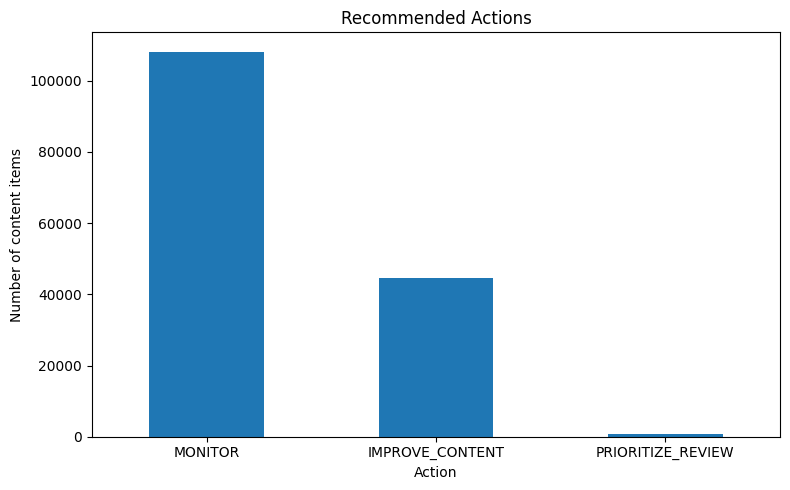


2. REASON CODE DISTRIBUTION


,count
reason_code,
R4_LOW_VOLUME_MONITOR,108205
R3_RANKING_OPPORTUNITY,44481
R1_CTR_POSITION_OPPORTUNITY,873


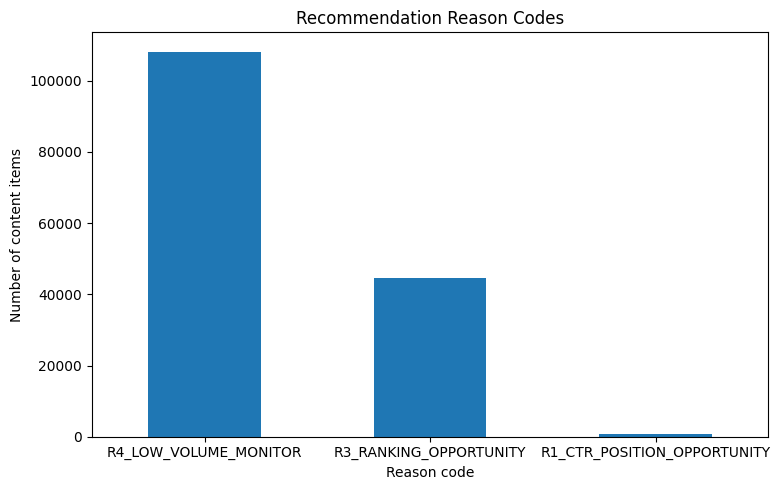


3. SCORE DISTRIBUTION


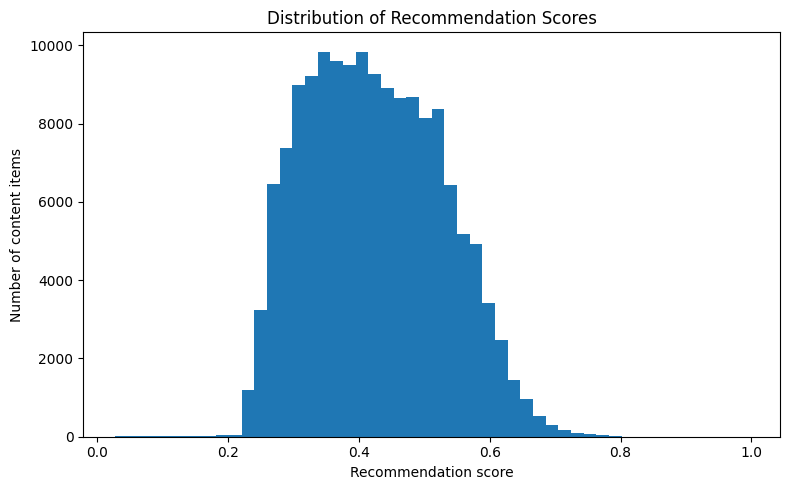


4. TOP 20 RECOMMENDATIONS


,rank,content_hash_id,action,reason_code,impressions_feb,clicks_feb,ctr_feb,avg_position_feb,score
0,1,content_c150891972f394a2,PRIORITIZE_REVIEW,R1_CTR_POSITION_OPPORTUNITY,41585.0,23.0,0.000553,3.397403,0.671039
1,2,content_a07d1e3236680189,PRIORITIZE_REVIEW,R1_CTR_POSITION_OPPORTUNITY,29223.0,17.0,0.000582,3.595764,0.654611
2,3,content_97d7732bcbfc6931,PRIORITIZE_REVIEW,R1_CTR_POSITION_OPPORTUNITY,21348.0,12.0,0.000562,3.115795,0.651936
3,4,content_c406f6bcaac8a477,PRIORITIZE_REVIEW,R1_CTR_POSITION_OPPORTUNITY,30545.0,1.0,0.000033,4.225831,0.647167
4,5,content_0c85ddc060b983a1,PRIORITIZE_REVIEW,R1_CTR_POSITION_OPPORTUNITY,23728.0,2.0,0.000084,3.616318,0.646702
5,6,content_2f6c3048d8e75f26,PRIORITIZE_REVIEW,R1_CTR_POSITION_OPPORTUNITY,17357.0,9.0,0.000519,3.022469,0.646298
6,7,content_0df17ae163625118,PRIORITIZE_REVIEW,R1_CTR_POSITION_OPPORTUNITY,35319.0,19.0,0.000538,4.927999,0.644479
7,8,content_894c99c720d52854,PRIORITIZE_REVIEW,R1_CTR_POSITION_OPPORTUNITY,27181.0,14.0,0.000515,4.169309,0.643507
8,9,content_37a6fac676c8cebb,PRIORITIZE_REVIEW,R1_CTR_POSITION_OPPORTUNITY,23624.0,9.0,0.000381,4.565400,0.633552
9,10,content_477135445684a92c,PRIORITIZE_REVIEW,R1_CTR_POSITION_OPPORTUNITY,25453.0,15.0,0.000589,4.912191,0.632567



5. SCORE VS CTR


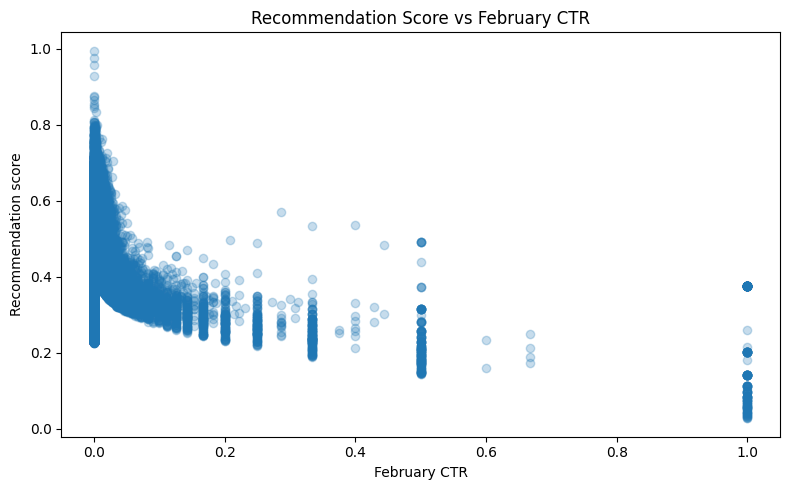


6. SCORE VS AVERAGE POSITION


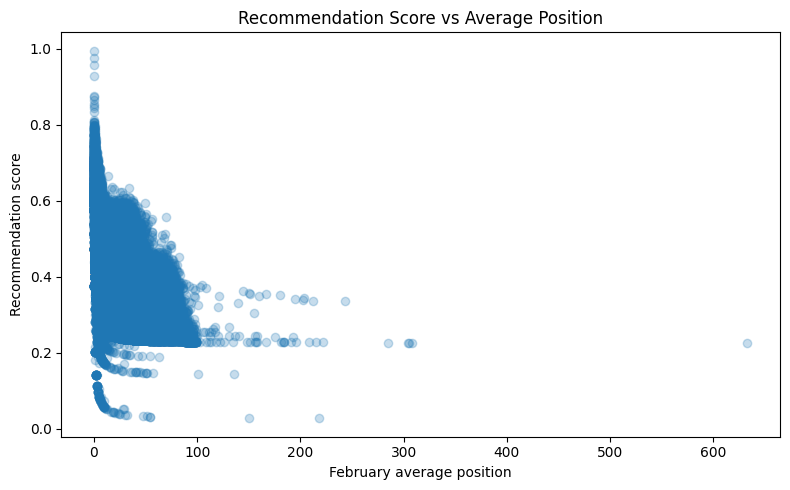


7. PAPER SUMMARY TABLE


,Metric,Value
0,Decision rows,153559.000000
1,Monitor,108205.000000
2,Improve content,44481.000000
3,Prioritize review,873.000000
4,Top recommendation score,0.995149
5,Median recommendation score,0.416685



SECTION 7 COMPLETE

Generated artifacts:
- action_distribution.png
- reason_code_distribution.png
- score_distribution.png
- score_vs_ctr.png
- score_vs_position.png
- top20_recommendations.csv
- paper_summary_table.csv


In [15]:
# SECTION 7 — Artifacts the paper embeds
#
# Generate the charts and tables that will be used in the deployed paper.
# All outputs are based on the February 2026 decision window.

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

print("SECTION 7 — PAPER ARTIFACTS")
print("=" * 60)

# ---------------------------------------------------------
# ARTIFACT 1 — ACTION DISTRIBUTION
# ---------------------------------------------------------

action_counts = recommendations["action"].value_counts()

print("\n1. ACTION DISTRIBUTION")
display(action_counts.to_frame("count"))

plt.figure(figsize=(8, 5))
action_counts.plot(kind="bar")
plt.title("Recommended Actions")
plt.xlabel("Action")
plt.ylabel("Number of content items")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    "action_distribution.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# ---------------------------------------------------------
# ARTIFACT 2 — REASON CODE DISTRIBUTION
# ---------------------------------------------------------

reason_counts = recommendations["reason_code"].value_counts()

print("\n2. REASON CODE DISTRIBUTION")
display(reason_counts.to_frame("count"))

plt.figure(figsize=(8, 5))
reason_counts.plot(kind="bar")
plt.title("Recommendation Reason Codes")
plt.xlabel("Reason code")
plt.ylabel("Number of content items")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    "reason_code_distribution.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# ---------------------------------------------------------
# ARTIFACT 3 — SCORE DISTRIBUTION
# ---------------------------------------------------------

print("\n3. SCORE DISTRIBUTION")

plt.figure(figsize=(8, 5))
plt.hist(recommendations["score"], bins=50)
plt.title("Distribution of Recommendation Scores")
plt.xlabel("Recommendation score")
plt.ylabel("Number of content items")
plt.tight_layout()

plt.savefig(
    "score_distribution.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# ---------------------------------------------------------
# ARTIFACT 4 — TOP 20 RECOMMENDATIONS TABLE
# ---------------------------------------------------------

top20 = recommendations.head(20).copy()

print("\n4. TOP 20 RECOMMENDATIONS")
display(top20)


# Save the table for the paper
top20.to_csv(
    "top20_recommendations.csv",
    index=False
)


# ---------------------------------------------------------
# ARTIFACT 5 — SCORE VS CTR
# ---------------------------------------------------------

print("\n5. SCORE VS CTR")

plt.figure(figsize=(8, 5))
plt.scatter(
    recommendations["ctr_feb"],
    recommendations["score"],
    alpha=0.25
)

plt.title("Recommendation Score vs February CTR")
plt.xlabel("February CTR")
plt.ylabel("Recommendation score")
plt.tight_layout()

plt.savefig(
    "score_vs_ctr.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# ---------------------------------------------------------
# ARTIFACT 6 — SCORE VS POSITION
# ---------------------------------------------------------

print("\n6. SCORE VS AVERAGE POSITION")

plt.figure(figsize=(8, 5))
plt.scatter(
    recommendations["avg_position_feb"],
    recommendations["score"],
    alpha=0.25
)

plt.title("Recommendation Score vs Average Position")
plt.xlabel("February average position")
plt.ylabel("Recommendation score")
plt.tight_layout()

plt.savefig(
    "score_vs_position.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# ---------------------------------------------------------
# ARTIFACT 7 — SUMMARY TABLE
# ---------------------------------------------------------

summary_table = pd.DataFrame({
    "Metric": [
        "Decision rows",
        "Monitor",
        "Improve content",
        "Prioritize review",
        "Top recommendation score",
        "Median recommendation score"
    ],
    "Value": [
        len(recommendations),
        int((recommendations["action"] == "MONITOR").sum()),
        int((recommendations["action"] == "IMPROVE_CONTENT").sum()),
        int((recommendations["action"] == "PRIORITIZE_REVIEW").sum()),
        recommendations["score"].max(),
        recommendations["score"].median()
    ]
})

print("\n7. PAPER SUMMARY TABLE")
display(summary_table)

summary_table.to_csv(
    "paper_summary_table.csv",
    index=False
)


print("\n" + "=" * 60)
print("SECTION 7 COMPLETE")
print("=" * 60)

print("\nGenerated artifacts:")
print("- action_distribution.png")
print("- reason_code_distribution.png")
print("- score_distribution.png")
print("- score_vs_ctr.png")
print("- score_vs_position.png")
print("- top20_recommendations.csv")
print("- paper_summary_table.csv")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
